# ICU Patient Outcome Prediction: Predictive Modeling
**Objective:** To build, evaluate, and interpret a machine learning model capable of predicting in-hospital mortality using the engineered clinical features developed during the exploratory data analysis (EDA) phase. 

Given the imbalanced nature of our dataset (14% mortality rate) and the critical healthcare context, we will prioritize precision-recall metrics and model explainability over raw accuracy.

## 1. Environment Setup & Data Ingestion

In [1]:
%pip install scikit-learn
%pip install xgboost
%pip install shap

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning & Evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix, PrecisionRecallDisplay

# Advanced Algorithms & Explainability
from xgboost import XGBClassifier
import shap

# Load the dataset (assuming preprocessing steps from 01_eda are applied)
# Replace 'icu_data_engineered.csv' with your actual saved dataset from the EDA phase
df = pd.read_csv('icu_data_engineered.csv')

# Separate features (X) and target (y)
X = df.drop(columns=['in_hospital_death', 'recordid'])
y = df['in_hospital_death']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (3600, 127)
Target shape: (3600,)


## 2. Train-Test Split and Preprocessing Pipeline
We utilize a stratified train-test split to ensure that the 14% mortality minority class is proportionally represented in both the training and evaluation sets. 

For preprocessing, we construct a scikit-learn Pipeline. While tree-based models like XGBoost can handle missing values natively, applying a median imputer and standardizing the features ensures stability and provides a clean baseline if we test distance-based algorithms later.

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# 1. Stratified split to maintain class ratios
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Identify numeric and categorical columns automatically
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

# 3. Create specific pipelines for both data types
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    # sparse_output=False ensures it returns a dense array for pandas
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) 
])

# 4. Combine them using a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 5. Fit and transform the training data, only transform testing data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# 6. Convert back to DataFrame (crucial for SHAP later)
# We must get the new feature names since OneHotEncoder creates new columns
feature_names = preprocessor.get_feature_names_out()

X_train_processed = pd.DataFrame(X_train_processed, columns=feature_names)
X_test_processed = pd.DataFrame(X_test_processed, columns=feature_names)

print("Pipeline executed successfully!")

Numeric features: 126
Categorical features: 1
Pipeline executed successfully!


In [4]:
import re

# Function to sanitize column names for XGBoost
def sanitize_columns(df):
    # Replace [, ], and < with an underscore
    regex = re.compile(r"\[|\]|<", re.IGNORECASE)
    df.columns = [regex.sub("_", str(col)) for col in df.columns]
    return df

# Apply the sanitization to both train and test sets
X_train_processed = sanitize_columns(X_train_processed)
X_test_processed = sanitize_columns(X_test_processed)

print("Feature names sanitized for XGBoost!")

Feature names sanitized for XGBoost!


## 3. XGBoost Classifier Training
We select XGBoost for this tabular clinical dataset due to its high performance and ability to capture non-linear relationships between physiological variables. 

To address the severe class imbalance without synthetically altering the data (which can distort clinical realities), we utilize the `scale_pos_weight` parameter. This heavily penalizes the model for missing the minority class (mortality), forcing it to prioritize identifying at-risk patients.

In [5]:
# Calculate class imbalance ratio for scale_pos_weight
majority_class = y_train.value_counts()[0]
minority_class = y_train.value_counts()[1]
imbalance_ratio = majority_class / minority_class

# Initialize XGBoost with the scale_pos_weight
xgb_model = XGBClassifier(
    scale_pos_weight=imbalance_ratio,
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    eval_metric='aucpr' # Optimize for Area Under the Precision-Recall Curve
)

# Train the model
xgb_model.fit(X_train_processed, y_train)
print("XGBoost model training complete.")

XGBoost model training complete.


## 4. Model Evaluation: Precision-Recall over Accuracy
In a healthcare setting, claiming 86% accuracy by simply predicting "everyone survives" is dangerously misleading. Instead, we evaluate our model using the Area Under the Precision-Recall Curve (PR-AUC) and the ROC-AUC. We also analyze the confusion matrix to understand the trade-off between false positives (unnecessary clinical alarms) and false negatives (missed deteriorations).

ROC-AUC Score: 0.8386
PR-AUC Score: 0.4516

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.87      0.90       619
           1       0.41      0.57      0.48       101

    accuracy                           0.83       720
   macro avg       0.67      0.72      0.69       720
weighted avg       0.85      0.83      0.84       720



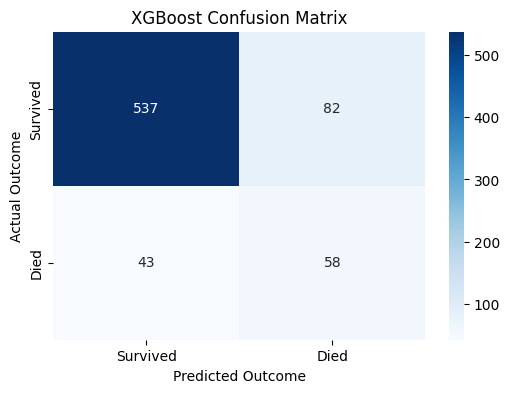

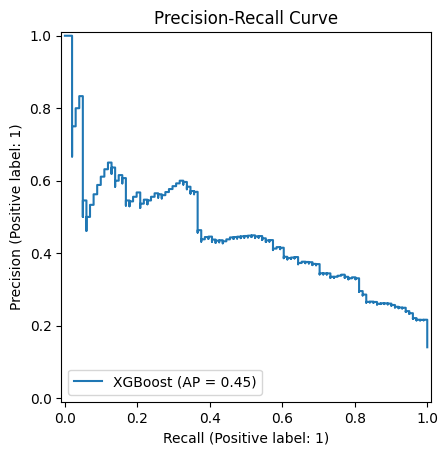

In [6]:
# Generate predictions
y_pred = xgb_model.predict(X_test_processed)
y_pred_proba = xgb_model.predict_proba(X_test_processed)[:, 1]

# Calculate specific metrics
roc_auc = roc_auc_score(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)

print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"PR-AUC Score: {pr_auc:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plot the Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Survived', 'Died'], yticklabels=['Survived', 'Died'])
plt.ylabel('Actual Outcome')
plt.xlabel('Predicted Outcome')
plt.title('XGBoost Confusion Matrix')
plt.show()

# Plot Precision-Recall Curve
PrecisionRecallDisplay.from_estimator(xgb_model, X_test_processed, y_test, name="XGBoost")
plt.title("Precision-Recall Curve")
plt.show()

## 5. Model Explainability with SHAP
A highly predictive model is useless in a clinical environment if physicians cannot trust its reasoning. We use SHAP (SHapley Additive exPlanations) to unpack the "black box" of the XGBoost model. This summary plot demonstrates exactly which features drive the model's mortality predictions, validating our EDA findings regarding multi-organ failure and metabolic stress.

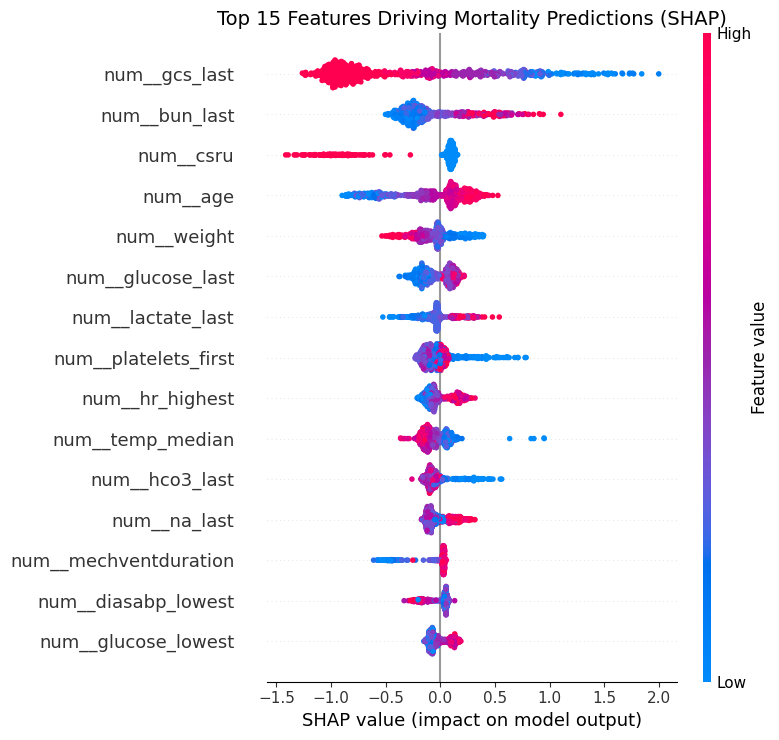

In [7]:
import xgboost as xgb
import shap

# 1. Force the test set into a strict float format
X_test_shap = X_test_processed.astype(float)

# 2. Convert to XGBoost's native DMatrix format
dtest = xgb.DMatrix(X_test_shap)

# 3. THE FIX: Ask XGBoost to calculate SHAP values natively!
# Using pred_contribs=True bypasses the shap.TreeExplainer version bug entirely.
# It returns a matrix where the last column is the base bias, and the rest are SHAP values.
contribs = xgb_model.get_booster().predict(dtest, pred_contribs=True)

# 4. Slice off the last column (bias) to get just the feature SHAP values
shap_values = contribs[:, :-1]

# 5. Plot using the SHAP library's visualization tool
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_shap, max_display=15, show=False)
plt.title("Top 15 Features Driving Mortality Predictions (SHAP)", fontsize=14)
plt.tight_layout()
plt.show()